**Assignment 2. Real-Time Data Processing with Pandas and NumPy. Done by Ayazhan Sailauova**

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [44]:
dataset = {
    "Time": ["10:00", "10:01", "10:02", "10:03", "10:04", "10:05", "10:06", "10:07", "10:08", "10:09", "10:10", "10:11"],
    "Room": ["C1.3.101", "C1.3.101", "C1.3.101", "C1.3.101", "C1.3.101", "C1.3.101", "C1.3.101", "C1.3.101", "C1.3.101", "C1.3.101", "C1.3.101", "C1.3.101"],
    "Temp_C": [21.5, 21.7, np.nan, 22.1, 22.3, 22.5, 22.6, 22.7, 22.9, 23.1, 23.2, 23.3],
    "CO2_ppm": [620, 650, 690, 720, np.nan, 780, 810, 830, 850, 900, 920, 950],
    "Occupancy": [18, 20, 22, 24, 25, 27, 29, np.nan, 31, 33, 35, 37],
    "Power_kW": [3.2, 3.4, 3.5, 3.8, 4.0, 4.2, 4.4, 4.6, 4.8, 5.1, 5.4, 5.7]
}

In [45]:
df = pd.DataFrame(dataset)
df

,Time,Room,Temp_C,CO2_ppm,Occupancy,Power_kW
0,10:00,C1.3.101,21.5,620.0,18.0,3.2
1,10:01,C1.3.101,21.7,650.0,20.0,3.4
2,10:02,C1.3.101,NaN,690.0,22.0,3.5
3,10:03,C1.3.101,22.1,720.0,24.0,3.8
4,10:04,C1.3.101,22.3,NaN,25.0,4.0
5,10:05,C1.3.101,22.5,780.0,27.0,4.2
6,10:06,C1.3.101,22.6,810.0,29.0,4.4
7,10:07,C1.3.101,22.7,830.0,NaN,4.6
8,10:08,C1.3.101,22.9,850.0,31.0,4.8
9,10:09,C1.3.101,23.1,900.0,33.0,5.1


**Part A — Data Quality**

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Time       12 non-null     object 
 1   Room       12 non-null     object 
 2   Temp_C     11 non-null     float64
 3   CO2_ppm    11 non-null     float64
 4   Occupancy  11 non-null     float64
 5   Power_kW   12 non-null     float64
dtypes: float64(4), object(2)
memory usage: 708.0+ bytes


In [47]:
df.isna().sum()

Time         0
Room         0
Temp_C       1
CO2_ppm      1
Occupancy    1
Power_kW     0
dtype: int64

In [48]:
df["Temp_C"] = df["Temp_C"].interpolate()

In [49]:
df["CO2_ppm"] = df["CO2_ppm"].interpolate(method="linear")

In [50]:
df["Occupancy"] = df["Occupancy"].ffill()

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Time       12 non-null     object 
 1   Room       12 non-null     object 
 2   Temp_C     12 non-null     float64
 3   CO2_ppm    12 non-null     float64
 4   Occupancy  12 non-null     float64
 5   Power_kW   12 non-null     float64
dtypes: float64(4), object(2)
memory usage: 708.0+ bytes


In [52]:
df = df.astype({
    "CO2_ppm": "int64",     
    "Occupancy": "int64",  
})

In [53]:
df

,Time,Room,Temp_C,CO2_ppm,Occupancy,Power_kW
0,10:00,C1.3.101,21.5,620,18,3.2
1,10:01,C1.3.101,21.7,650,20,3.4
2,10:02,C1.3.101,21.9,690,22,3.5
3,10:03,C1.3.101,22.1,720,24,3.8
4,10:04,C1.3.101,22.3,750,25,4.0
5,10:05,C1.3.101,22.5,780,27,4.2
6,10:06,C1.3.101,22.6,810,29,4.4
7,10:07,C1.3.101,22.7,830,29,4.6
8,10:08,C1.3.101,22.9,850,31,4.8
9,10:09,C1.3.101,23.1,900,33,5.1


**Part B — Streaming Window Statistics**

In [54]:
df["Temp_rolling_mean"] = df["Temp_C"].rolling(3).mean()

In [55]:
df["CO2_rolling_mean"] = df["CO2_ppm"].rolling(3).mean()

In [56]:
df["Power_rolling_mean"] = df["Power_kW"].rolling(3).mean()

In [57]:
df

,Time,Room,Temp_C,CO2_ppm,Occupancy,Power_kW,Temp_rolling_mean,CO2_rolling_mean,Power_rolling_mean
0,10:00,C1.3.101,21.5,620,18,3.2,NaN,NaN,NaN
1,10:01,C1.3.101,21.7,650,20,3.4,NaN,NaN,NaN
2,10:02,C1.3.101,21.9,690,22,3.5,21.700000,653.333333,3.366667
3,10:03,C1.3.101,22.1,720,24,3.8,21.900000,686.666667,3.566667
4,10:04,C1.3.101,22.3,750,25,4.0,22.100000,720.000000,3.766667
5,10:05,C1.3.101,22.5,780,27,4.2,22.300000,750.000000,4.000000
6,10:06,C1.3.101,22.6,810,29,4.4,22.466667,780.000000,4.200000
7,10:07,C1.3.101,22.7,830,29,4.6,22.600000,806.666667,4.400000
8,10:08,C1.3.101,22.9,850,31,4.8,22.733333,830.000000,4.600000
9,10:09,C1.3.101,23.1,900,33,5.1,22.900000,860.000000,4.833333


In [58]:
rolling_mean_table = df.iloc[2:7][["Time", "Temp_rolling_mean", "CO2_rolling_mean", "Power_rolling_mean"]]
rolling_mean_table.round(2)

,Time,Temp_rolling_mean,CO2_rolling_mean,Power_rolling_mean
2,10:02,21.70,653.33,3.37
3,10:03,21.90,686.67,3.57
4,10:04,22.10,720.00,3.77
5,10:05,22.30,750.00,4.00
6,10:06,22.47,780.00,4.20


**Part C — Feature Engineering**

In [59]:
df["Occupancy_density"] = df["Occupancy"] / 40

In [60]:
df["Energy_per_student"] = df["Power_kW"] / df["Occupancy"]

In [61]:
df["Comfort_flag"] = (df["CO2_ppm"] <= 1000) & (df["Temp_C"] >= 20.0) & (df["Temp_C"] <= 24.0)

In [62]:
df["Co2_growth_rate"] = df["CO2_ppm"].diff()

In [63]:
df

,Time,Room,Temp_C,CO2_ppm,Occupancy,Power_kW,Temp_rolling_mean,CO2_rolling_mean,Power_rolling_mean,Occupancy_density,Energy_per_student,Comfort_flag,Co2_growth_rate
0,10:00,C1.3.101,21.5,620,18,3.2,NaN,NaN,NaN,0.450,0.177778,True,NaN
1,10:01,C1.3.101,21.7,650,20,3.4,NaN,NaN,NaN,0.500,0.170000,True,30.0
2,10:02,C1.3.101,21.9,690,22,3.5,21.700000,653.333333,3.366667,0.550,0.159091,True,40.0
3,10:03,C1.3.101,22.1,720,24,3.8,21.900000,686.666667,3.566667,0.600,0.158333,True,30.0
4,10:04,C1.3.101,22.3,750,25,4.0,22.100000,720.000000,3.766667,0.625,0.160000,True,30.0
5,10:05,C1.3.101,22.5,780,27,4.2,22.300000,750.000000,4.000000,0.675,0.155556,True,30.0
6,10:06,C1.3.101,22.6,810,29,4.4,22.466667,780.000000,4.200000,0.725,0.151724,True,30.0
7,10:07,C1.3.101,22.7,830,29,4.6,22.600000,806.666667,4.400000,0.725,0.158621,True,20.0
8,10:08,C1.3.101,22.9,850,31,4.8,22.733333,830.000000,4.600000,0.775,0.154839,True,20.0
9,10:09,C1.3.101,23.1,900,33,5.1,22.900000,860.000000,4.833333,0.825,0.154545,True,50.0


**Part D — Statistical Analysis**

In [64]:
mean_t = df["Temp_C"].mean()
median_t = df["Temp_C"].median()
min_t = df["Temp_C"].min()
max_t = df["Temp_C"].max()
print("Mean Temperature = ", mean_t.round(2), "\n",
      "Median Temperature = ", median_t, "\n",
      "Minimum Temperature = ", min_t, "\n",
      "Maximum Temperature = ", max_t, "\n")

Mean Temperature =  22.48 
 Median Temperature =  22.55 
 Minimum Temperature =  21.5 
 Maximum Temperature =  23.3 



In [75]:
mean_CO2 = df["CO2_ppm"].mean()
max_CO2 = df["CO2_ppm"].max()
print("Mean CO2 = ", mean_CO2.round(2), "\n",
     "Max CO2 = ", max_CO2)

Mean CO2 =  789.17 
 Max CO2 =  950


In [76]:
highest_power = df["Power_kW"].idxmax()
highest_power_time = df.loc[highest_power, "Time"]
highest_power_value = df.loc[highest_power, "Power_kW"]
print(f"The time with highest power consumption of {highest_power_value} was at {highest_power_time}")

The time with highest power consumption of 5.7 was at 10:11


In [77]:
corr = df[["Occupancy", "Power_kW"]].corr()
print("The correlation between Occupancy and Power Consuption = \n", corr)

The correlation between Occupancy and Power Consuption = 
            Occupancy  Power_kW
Occupancy   1.000000  0.994587
Power_kW    0.994587  1.000000


There is a strong positive correlation between the class occupancy and power consuption. The correlation coefficiant of 0.994 indicates that as the occupancy increases the power in kW also increases. Starting with the energy consumption of 3.2 kW among occupancy 18, this value increased to 5.7 with occupancy 37.

**Part E — Visualization and Engineering Interpretation**

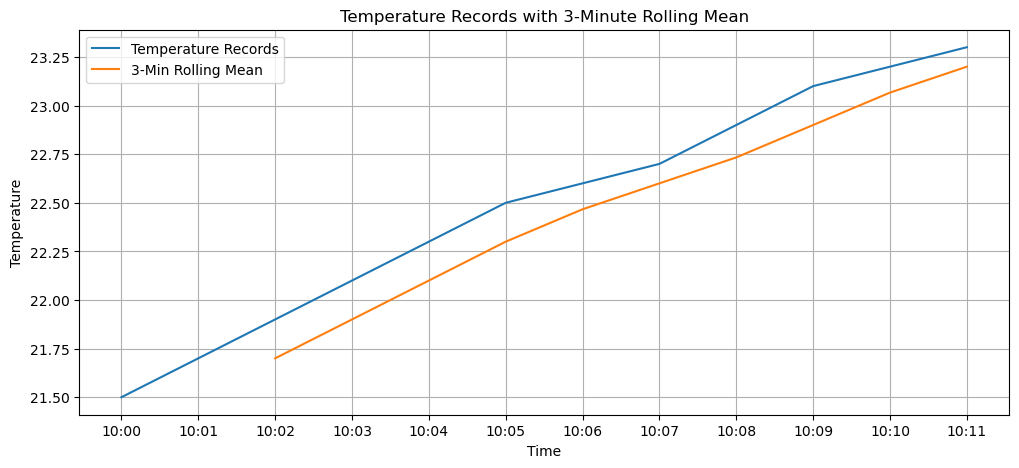

In [78]:
plt.figure(figsize=(12, 5))

sns.lineplot(x="Time", 
             y="Temp_C", 
             data=df, 
             label='Temperature Records')

sns.lineplot(x="Time", 
             y="Temp_rolling_mean", 
             data=df, 
             label='3-Min Rolling Mean')

plt.xlabel('Time')
plt.ylabel('Temperature')
plt.title('Temperature Records with 3-Minute Rolling Mean')

pos = df["Time"].tolist()  
lab = df["Time"].tolist()

plt.xticks(ticks=range(len(pos)), labels=lab, rotation=0)

plt.legend()
plt.grid(True)
plt.show()

The temperature records increase over the 11 minutes, from 21.5 (C) at 10:00 to just above 23.3 (C) at 10:11. There is a short period of time when the temperature records fluctuate, between 10:05 and 10:09. This can imply the period of time when other external factors influenced the values. The line that represents the rolling mean values follows the similar trend. However, it grows slightly from approximately 21.7 (C) at 10:02 to nearly 23.2 (C) at 10:11. The rolling mean function standardized the values.

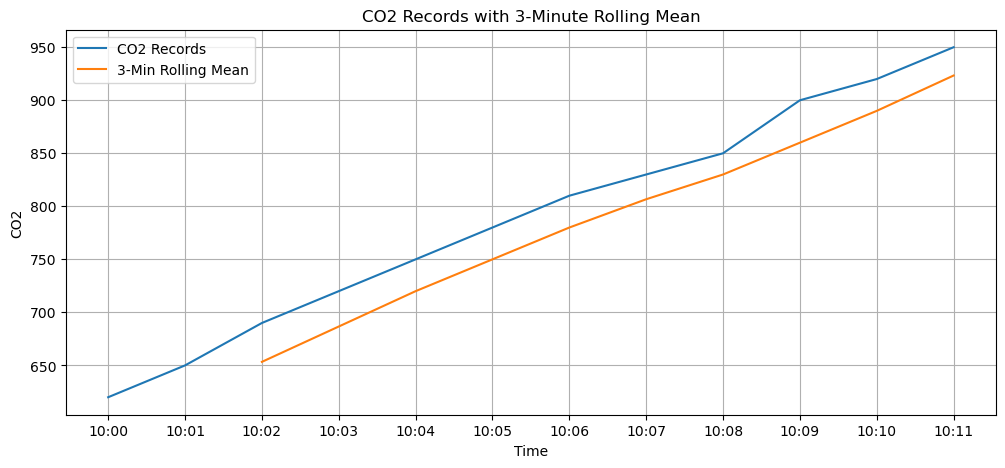

In [79]:
plt.figure(figsize=(12, 5))

sns.lineplot(x="Time", 
             y="CO2_ppm", 
             data=df, 
             label='CO2 Records')

sns.lineplot(x="Time", 
             y="CO2_rolling_mean", 
             data=df, 
             label='3-Min Rolling Mean')

plt.xlabel('Time')
plt.ylabel('CO2')
plt.title('CO2 Records with 3-Minute Rolling Mean')

pos = df["Time"].tolist()  
lab = df["Time"].tolist()

plt.xticks(ticks=range(len(pos)), labels=lab, rotation=0)

plt.legend()
plt.grid(True)
plt.show()

There is a significant increase of CO2 records with periods of fluctuations and the highest value of 950 ppm. However, this value does not exceeds the threshold of comfort flag. The rolling mean of CO2_pm generalizes an upward trend to more steep growth.

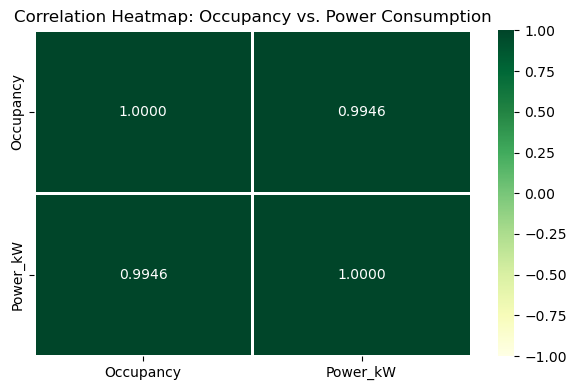

In [80]:
plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, fmt=".4f", cmap="YlGn", vmin=-1, vmax=1, linewidths=1)        
plt.title("Correlation Heatmap: Occupancy vs. Power Consumption")
plt.tight_layout()
plt.show()

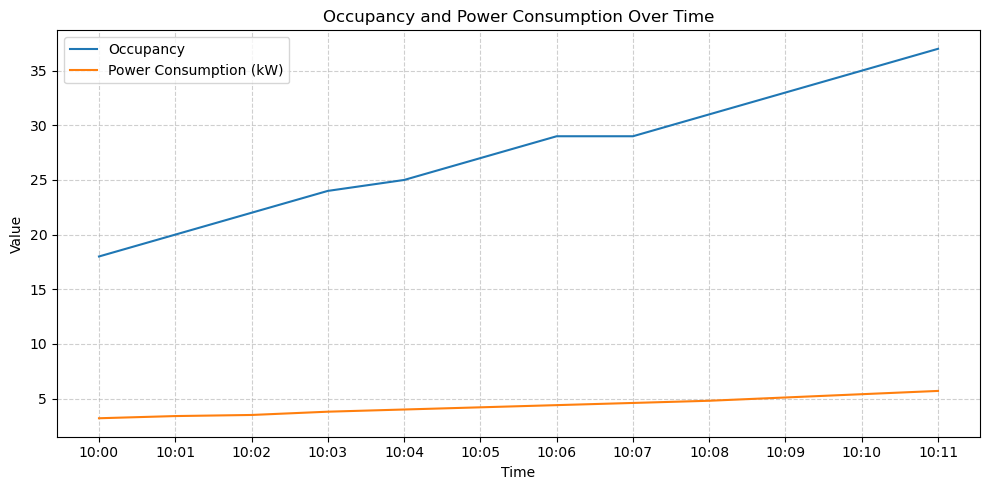

In [81]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x='Time', y='Occupancy', label='Occupancy')
sns.lineplot(data=df, x='Time', y='Power_kW', label='Power Consumption (kW)')

plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Occupancy and Power Consumption Over Time')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

Both lines follow an upward trend, meaning that records of occupancy and power consumption increase throughout the period with correlation coefficiant of 0.994.